# Multi-Class Attack Classification using Random Forest

## Step 1: Import Required Libraries

## Part 1: Raw Data Exploration and Preprocessing

### Load Raw Data from CSV

In [21]:
# Load raw data from all days
import os
import glob

raw_data_path = '../data/raw/'

# Load all datasets (excluding _plus files for now)
raw_files = [f for f in glob.glob(raw_data_path + '*.csv') if '_plus' not in f]
raw_files = sorted(raw_files)

print(f"Found {len(raw_files)} raw data files:")
for f in raw_files:
    print(f"  - {os.path.basename(f)}")

# Load the first dataset (Monday) as example
raw_data = pd.read_csv(raw_files[0])
print(f"\n\nLoaded: {os.path.basename(raw_files[0])}")
print(f"Shape: {raw_data.shape}")
print(f"\nFirst few rows:")
print(raw_data.head())

Found 5 raw data files:
  - friday.csv
  - monday.csv
  - thursday.csv
  - tuesday.csv
  - wednesday.csv


Loaded: friday.csv
Shape: (547557, 89)

First few rows:
   Src IP dec  Src Port  Dst IP dec  Dst Port  Protocol Timestamp  \
0  3232238130     56108  3232238083      3268         6   59:50.3   
1  3232238130     42144  3232238083       389         6   59:50.3   
2   134610945         0   134219268         0         0   00:31.4   
3  3232238105      5353  3758096635      5353        17   00:42.9   
4  3232238105       123   301796989       123        17   00:42.4   

   Flow Duration  Total Fwd Packet  Total Bwd packets  \
0      112740690                32                 16   
1      112740560                32                 16   
2      113757377               545                  0   
3       91997219               388                  0   
4       66966070                 6                  6   

   Total Length of Fwd Packet  ...  Active Min    Idle Mean      Idle Std  \
0 

### Raw Data Information and Statistics

In [12]:
print("Column Names and Types:")
print(raw_data.dtypes)

print("\n\nData Info:")
print(raw_data.info())

print("\n\nBasic Statistics:")
print(raw_data.describe())

print("\n\nMissing Values:")
missing = raw_data.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values")

print("\n\nLabel Distribution:")
print(raw_data['Label'].value_counts())

print("\n\nAttempted Category Distribution:")
print(raw_data['Attempted Category'].value_counts())

Column Names and Types:
Src IP dec              int64
Src Port                int64
Dst IP dec              int64
Dst Port                int64
Protocol                int64
                        ...  
ICMP Code               int64
ICMP Type               int64
Total TCP Flow Time     int64
Label                  object
Attempted Category      int64
Length: 89, dtype: object


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 547557 entries, 0 to 547556
Data columns (total 89 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Src IP dec                  547557 non-null  int64  
 1   Src Port                    547557 non-null  int64  
 2   Dst IP dec                  547557 non-null  int64  
 3   Dst Port                    547557 non-null  int64  
 4   Protocol                    547557 non-null  int64  
 5   Timestamp                   547557 non-null  object 
 6   Flow Duration              

### Data Preprocessing from Raw Data

In [22]:
# Step 1: Drop unnecessary columns
print("Step 1: Dropping unnecessary columns...")
columns_to_drop = ['Src IP dec', 'Src Port', 'Dst IP dec', 'Dst Port', 'Timestamp', 'Attempted Category']
raw_data_clean = raw_data.copy()
raw_data_clean = raw_data_clean.drop(columns=[col for col in columns_to_drop if col in raw_data_clean.columns])

print(f"Columns after dropping: {raw_data_clean.shape[1]}")

# Step 2: Extract target variable
print("\nStep 2: Extracting target variable...")
y_raw = raw_data_clean['Label']
X_raw = raw_data_clean.drop('Label', axis=1)

print(f"Features shape: {X_raw.shape}")
print(f"Target shape: {y_raw.shape}")
print(f"Target classes: {y_raw.unique()}")

# Step 3: Handle missing and infinite values
print("\nStep 3: Handling missing and infinite values...")
print(f"Missing values before: {X_raw.isnull().sum().sum()}")

X_raw = X_raw.fillna(X_raw.mean(numeric_only=True))
X_raw = X_raw.replace([np.inf, -np.inf], np.nan)
X_raw = X_raw.fillna(X_raw.mean(numeric_only=True))

print(f"Missing values after: {X_raw.isnull().sum().sum()}")

# Step 4: Feature scaling
print("\nStep 4: Feature scaling...")
scaler_raw = StandardScaler()
X_raw_scaled = scaler_raw.fit_transform(X_raw)
X_raw_scaled = pd.DataFrame(X_raw_scaled, columns=X_raw.columns)

print(f"Scaled data shape: {X_raw_scaled.shape}")
print(f"\nPreprocessed data ready for model training!")

Step 1: Dropping unnecessary columns...
Columns after dropping: 83

Step 2: Extracting target variable...
Features shape: (547557, 82)
Target shape: (547557,)
Target classes: ['BENIGN' 'Botnet - Attempted' 'Botnet' 'Portscan' 'DDoS']

Step 3: Handling missing and infinite values...
Missing values before: 0
Missing values after: 0

Step 4: Feature scaling...
Scaled data shape: (547557, 82)

Preprocessed data ready for model training!


## Part 2: Random Forest Classification on Raw Data

### Train-Test Split

In [23]:
# Split data into training and testing sets
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw_scaled, 
    y_raw, 
    test_size=0.2,
    random_state=42,
    stratify=y_raw
)

print(f"Training set size: {X_train_raw.shape[0]}")
print(f"Testing set size: {X_test_raw.shape[0]}")
print(f"Number of features: {X_train_raw.shape[1]}")
print(f"\nTraining set class distribution:")
print(y_train_raw.value_counts())
print(f"\nTesting set class distribution:")
print(y_test_raw.value_counts())

Training set size: 438045
Testing set size: 109512
Number of features: 82

Training set class distribution:
Label
BENIGN                230835
Portscan              127253
DDoS                   76115
Botnet - Attempted      3253
Botnet                   589
Name: count, dtype: int64

Testing set class distribution:
Label
BENIGN                57709
Portscan              31813
DDoS                  19029
Botnet - Attempted      814
Botnet                  147
Name: count, dtype: int64


### Train Random Forest Classifier

In [24]:
print("Training Random Forest Classifier on Raw Data...")

# Initialize Random Forest with optimized hyperparameters
rf_raw = RandomForestClassifier(
    n_estimators=200,          # Increased number of trees for better performance
    max_depth=25,              # Maximum depth of trees
    min_samples_split=5,       # Minimum samples to split a node
    min_samples_leaf=2,        # Minimum samples at leaf
    max_features='sqrt',       # Use sqrt of features at each split
    random_state=42,
    n_jobs=-1,                 # Use all available processors
    class_weight='balanced'    # Handle class imbalance
)

# Train the model
rf_raw.fit(X_train_raw, y_train_raw)
print("✓ Training completed!")

# Feature importance
feature_importance_raw = pd.DataFrame({
    'feature': X_raw_scaled.columns,
    'importance': rf_raw.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n{'='*50}")
print("Top 15 Most Important Features:")
print(f"{'='*50}")
for idx, (feat, imp) in enumerate(feature_importance_raw.head(15).values, 1):
    print(f"{idx:2d}. {feat:40s} : {imp:.6f}")

Training Random Forest Classifier on Raw Data...
✓ Training completed!

Top 15 Most Important Features:
 1. Bwd Segment Size Avg                     : 0.061739
 2. Bwd Packet Length Mean                   : 0.058812
 3. Subflow Bwd Bytes                        : 0.054029
 4. Fwd Packets/s                            : 0.050134
 5. Bwd Packet Length Std                    : 0.044312
 6. Packet Length Mean                       : 0.044022
 7. Flow IAT Min                             : 0.043922
 8. Flow IAT Mean                            : 0.038745
 9. Fwd Packet Length Mean                   : 0.038417
10. Bwd Packet Length Max                    : 0.037861
11. Fwd Packet Length Max                    : 0.037532
12. Total Length of Fwd Packet               : 0.035851
13. Flow IAT Max                             : 0.035848
14. Packet Length Max                        : 0.034426
15. Total Length of Bwd Packet               : 0.032402


### Model Evaluation on Test Set

In [25]:
# Make predictions on test set
y_pred_raw = rf_raw.predict(X_test_raw)
y_pred_raw_proba = rf_raw.predict_proba(X_test_raw)

# Calculate metrics
accuracy_raw = accuracy_score(y_test_raw, y_pred_raw)
f1_raw = f1_score(y_test_raw, y_pred_raw, average='weighted')
f1_macro = f1_score(y_test_raw, y_pred_raw, average='macro')

print(f"{'='*50}")
print("PERFORMANCE METRICS")
print(f"{'='*50}")
print(f"Accuracy:          {accuracy_raw:.4f} ({accuracy_raw*100:.2f}%)")
print(f"F1 Score (Weighted): {f1_raw:.4f}")
print(f"F1 Score (Macro):    {f1_macro:.4f}")

# Detailed classification report
print(f"\n{'='*50}")
print("CLASSIFICATION REPORT")
print(f"{'='*50}")
print(classification_report(y_test_raw, y_pred_raw))

# Confusion matrix
cm_raw = confusion_matrix(y_test_raw, y_pred_raw)
print(f"\n{'='*50}")
print("CONFUSION MATRIX")
print(f"{'='*50}")
print(cm_raw)

PERFORMANCE METRICS
Accuracy:          0.9998 (99.98%)
F1 Score (Weighted): 0.9998
F1 Score (Macro):    0.9972

CLASSIFICATION REPORT
                    precision    recall  f1-score   support

            BENIGN       1.00      1.00      1.00     57709
            Botnet       1.00      1.00      1.00       147
Botnet - Attempted       0.97      1.00      0.99       814
              DDoS       1.00      1.00      1.00     19029
          Portscan       1.00      1.00      1.00     31813

          accuracy                           1.00    109512
         macro avg       0.99      1.00      1.00    109512
      weighted avg       1.00      1.00      1.00    109512


CONFUSION MATRIX
[[57687     0    22     0     0]
 [    0   147     0     0     0]
 [    1     0   813     0     0]
 [    0     0     0 19029     0]
 [    1     0     0     0 31812]]


### Visualizations

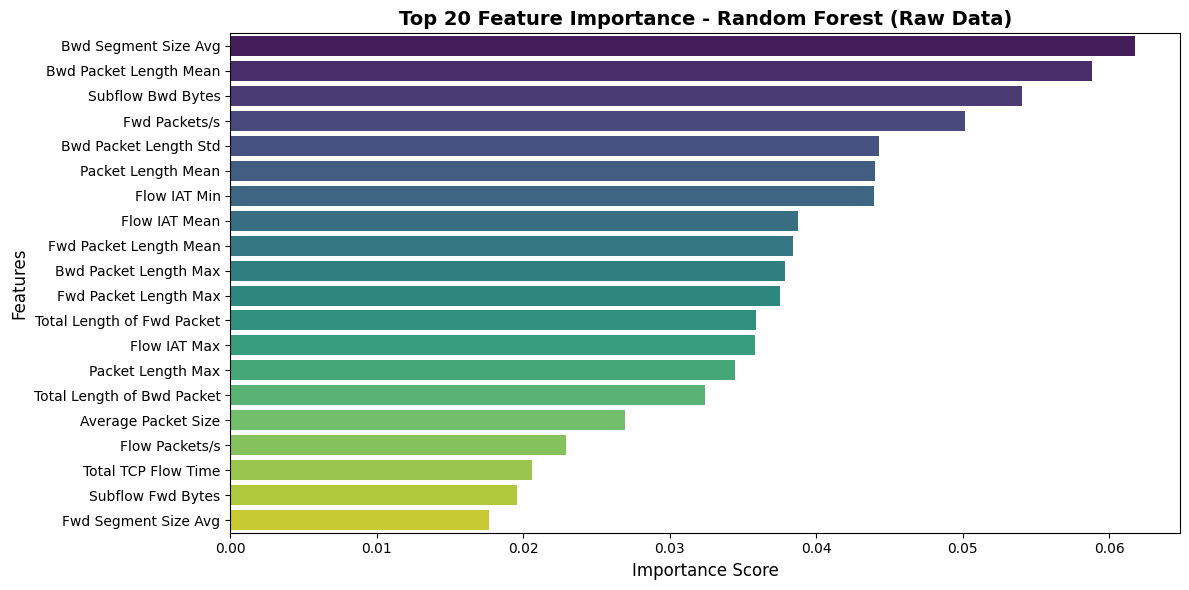

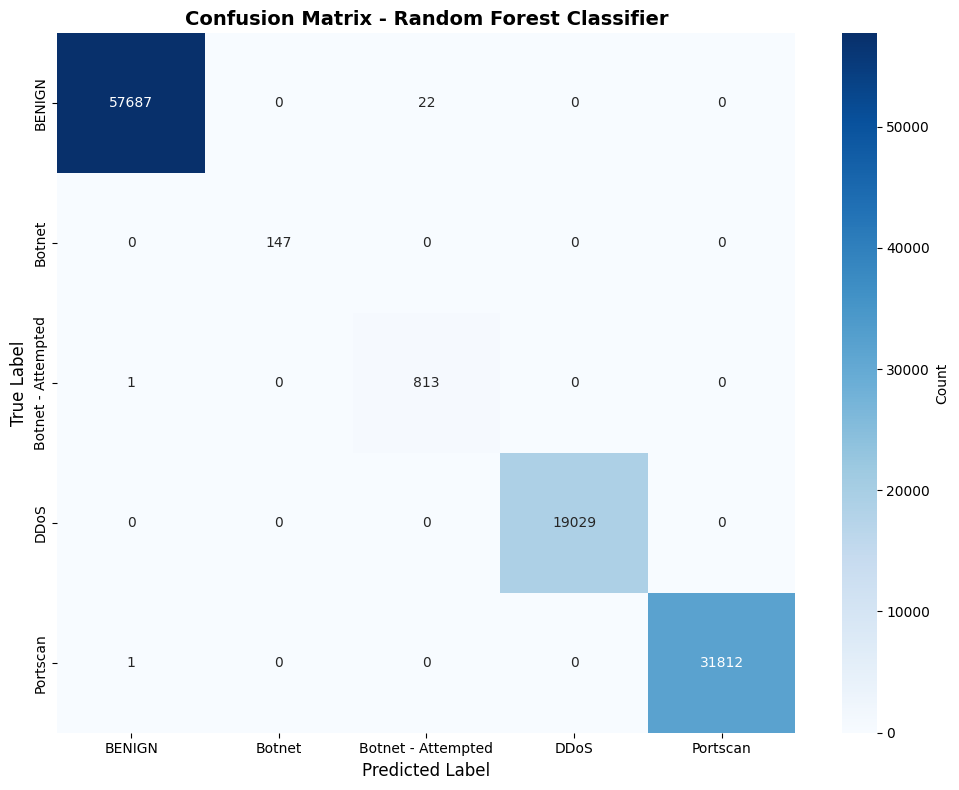

In [26]:
# 1. Feature Importance Plot
plt.figure(figsize=(12, 6))
top_features = feature_importance_raw.head(20)
sns.barplot(data=top_features, x='importance', y='feature', palette='viridis')
plt.title('Top 20 Feature Importance - Random Forest (Raw Data)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

# 2. Confusion Matrix Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues', 
            xticklabels=rf_raw.classes_, 
            yticklabels=rf_raw.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Random Forest Classifier', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

### Sample Predictions with Confidence Scores

In [27]:
# Create prediction results dataframe
results_raw = pd.DataFrame({
    'True_Label': y_test_raw.values,
    'Predicted_Label': y_pred_raw,
    'Prediction_Confidence': y_pred_raw_proba.max(axis=1),
    'Correct': y_pred_raw == y_test_raw.values
})

print("Sample Predictions (with confidence scores):")
print(results_raw.head(15))

print(f"\n\nPrediction Accuracy Statistics:")
print(f"Total predictions: {len(results_raw)}")
print(f"Correct predictions: {results_raw['Correct'].sum()}")
print(f"Incorrect predictions: {(~results_raw['Correct']).sum()}")
print(f"Accuracy: {results_raw['Correct'].sum() / len(results_raw) * 100:.2f}%")
print(f"\nAverage confidence: {results_raw['Prediction_Confidence'].mean():.4f}")
print(f"Min confidence: {results_raw['Prediction_Confidence'].min():.4f}")
print(f"Max confidence: {results_raw['Prediction_Confidence'].max():.4f}")

Sample Predictions (with confidence scores):
   True_Label Predicted_Label  Prediction_Confidence  Correct
0      BENIGN          BENIGN               1.000000     True
1      BENIGN          BENIGN               1.000000     True
2    Portscan        Portscan               0.999972     True
3    Portscan        Portscan               0.999971     True
4      BENIGN          BENIGN               1.000000     True
5    Portscan        Portscan               0.999972     True
6        DDoS            DDoS               1.000000     True
7    Portscan        Portscan               0.999969     True
8      BENIGN          BENIGN               1.000000     True
9      BENIGN          BENIGN               1.000000     True
10   Portscan        Portscan               0.999970     True
11     BENIGN          BENIGN               1.000000     True
12       DDoS            DDoS               1.000000     True
13     BENIGN          BENIGN               1.000000     True
14     BENIGN          BE

### Save the Trained Model

In [28]:
# Save the trained model and scaler
model_path = '../models/random_forest_raw_data.joblib'
scaler_path = '../models/scaler_raw_data.joblib'

joblib.dump(rf_raw, model_path)
joblib.dump(scaler_raw, scaler_path)

print(f"✓ Model saved to: {model_path}")
print(f"✓ Scaler saved to: {scaler_path}")

# Create and display model summary
print(f"\n{'='*60}")
print("MODEL SUMMARY")
print(f"{'='*60}")
summary_data = {
    'Model Type': 'Random Forest Classifier',
    'Training Data': os.path.basename(raw_files[0]),
    'Training Samples': X_train_raw.shape[0],
    'Testing Samples': X_test_raw.shape[0],
    'Number of Features': X_train_raw.shape[1],
    'Number of Classes': len(rf_raw.classes_),
    'Classes': ', '.join(rf_raw.classes_),
    'n_estimators': rf_raw.n_estimators,
    'max_depth': rf_raw.max_depth,
    'Accuracy': f"{accuracy_raw:.4f}",
    'F1-Score (Weighted)': f"{f1_raw:.4f}",
    'F1-Score (Macro)': f"{f1_macro:.4f}"
}

for key, value in summary_data.items():
    print(f"{key:.<30} {value}")
print(f"{'='*60}")

✓ Model saved to: ../models/random_forest_raw_data.joblib
✓ Scaler saved to: ../models/scaler_raw_data.joblib

MODEL SUMMARY
Model Type.................... Random Forest Classifier
Training Data................. friday.csv
Training Samples.............. 438045
Testing Samples............... 109512
Number of Features............ 82
Number of Classes............. 5
Classes....................... BENIGN, Botnet, Botnet - Attempted, DDoS, Portscan
n_estimators.................. 200
max_depth..................... 25
Accuracy...................... 0.9998
F1-Score (Weighted)........... 0.9998
F1-Score (Macro).............. 0.9972
